In [10]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind

In [2]:
# List of paths with .csv files
folder_names  = [
        "/mnt/c/users/helen/Desktop/U2OS_WT",
        "/mnt/c/users/helen/Desktop/U2OS_As_2h",
        "/mnt/c/users/helen/Desktop/U2OS_As_4h",
]

folders = [Path(f) for f in folder_names]

In [3]:
# Data loading into single dataframe
dfs = []

for folder in folders:
    for file in folder.glob("*.csv"):

        df = pd.read_csv(file)

        # Add file name column
        df["file_name"] = file.stem

        dfs.append(df)

    # Combine all dataframes
    data = pd.concat(dfs, ignore_index=True)

    # Column ordering
    data = data[
        ["file_name", "ROI", "Area", "Mean"]
    ]

    # Rename ROI column to remove the suffix after the underscore
    data["ROI"] = data["ROI"].apply(lambda x: x.split("_")[0])
    
# Add new sample_name column
data['sample_name'] = data['file_name'].apply(lambda x: 'WT' if 'NO_AS' in x else ('Sodium_arsenite_2h' if '2h' in x else 'Sodium_arsenite_4h'))

In [4]:
# Optional: Save the combined dataframe to a new CSV file
data.to_csv("/mnt/c/users/helen/Desktop/combined_data.csv", index=False, sep=";", decimal=",")

In [5]:
data.head()

,file_name,ROI,Area,Mean,sample_name
0,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_01...,Nucleus,283.320,2.998,WT
1,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_01...,Whole,1186.204,0.821,WT
2,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_01...,Cytoplasm,903.206,0.138,WT
3,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_02...,Nucleus,249.577,27.742,WT
4,C2_1_MP_U2OS_fixed_WT_NO_AS_001.nd2_(series_02...,Whole,545.672,15.616,WT


In [6]:
# Filtration of outliters
data = data[data['Mean'] < 20]

In [7]:
# Brief statistical summary of the data
data.groupby(['sample_name', 'ROI']).agg({'Area': ['mean', 'std', 'count'], 'Mean': ['mean', 'std']})

Area                        Mean          
                                    mean         std count      mean       std
sample_name        ROI                                                        
Sodium_arsenite_2h Cytoplasm  560.791880  260.854993    25  1.255640  1.324545
                   Nucleus    212.413565   83.967517    23  3.913870  2.543355
                   Whole      775.838320  303.297478    25  2.801800  3.612417
Sodium_arsenite_4h Cytoplasm  555.904407  254.821495    27  2.235222  3.259078
                   Nucleus    278.368760  123.421060    25  5.847360  4.132669
                   Whole      820.943115  350.695495    26  3.046192  2.615713
WT                 Cytoplasm  542.226931  351.358621    29  1.226414  1.304359
                   Nucleus    246.688692   75.491497    26  4.336500  3.030501
                   Whole      772.272379  394.548491    29  3.218793  4.055540

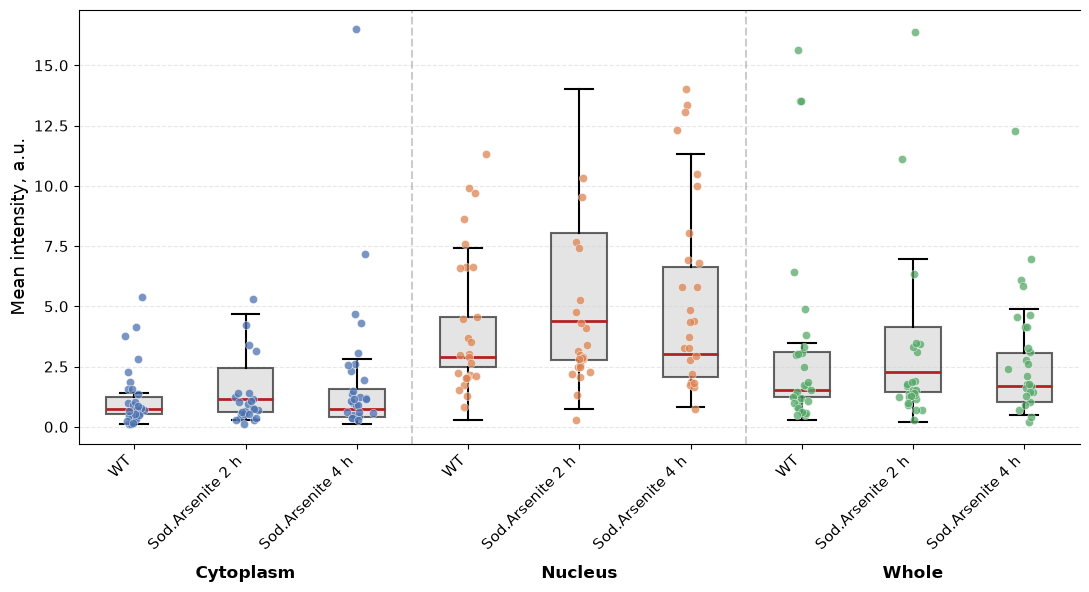

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))

# Order of groups
roi_order = ["Cytoplasm", "Nucleus", "Whole"]
sample_order = ["WT", "Sodium_arsenite_2h", "Sodium_arsenite_4h"]

# Your custom sample names for x-axis
sample_labels = {
    "WT": "WT",
    "Sodium_arsenite_2h": "Sod.Arsenite 2 h",
    "Sodium_arsenite_4h": "Sod.Arsenite 4 h",
}

# -------------------------------------------------------
# Color boxes according to ROI
# -------------------------------------------------------
roi_colors = {
    "Cytoplasm": "#4C72B0",   # blue
    "Nucleus": "#DD8452",     # orange
    "Whole": "#55A868",       # green
}

# Prepare data in desired order
groups = []
labels = []
positions = []

pos = 1
for roi in roi_order:
    for sample in sample_order:
        values = data.loc[
            (data["ROI"] == roi) & (data["sample_name"] == sample),
            "Mean"
        ].dropna()

        groups.append(values)
        labels.append(sample_labels[sample])
        positions.append(pos)
        pos += 1


# -------------------------------------------------------
# Boxplots: all light gray
# -------------------------------------------------------
data.boxplot(
    column="Mean",
    by=["ROI", "sample_name"],
    ax=ax,
    grid=False,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightgray",
                  edgecolor="black",
                  linewidth=1.5,
                  alpha=0.6),
    medianprops=dict(color="firebrick", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)


# -------------------------------------------------------
# Overlay individual points
# -------------------------------------------------------
for i, (roi, sample) in enumerate(
    [(roi, sample) for roi in roi_order for sample in sample_order],
    start=1
):
    values = data.loc[
        (data["ROI"] == roi) & (data["sample_name"] == sample),
        "Mean"
    ].dropna()

    x = np.random.normal(i, 0.05, len(values))

    ax.scatter(
        x,
        values,
        color=roi_colors[roi],
        edgecolor="white",
        linewidth=0.4,
        s=35,
        alpha=0.75,
        zorder=3,
    )
    
# X-axis sample labels
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha="right")

# ROI subgroup names below x-axis
roi_centers = {
    "Cytoplasm": 2,
    "Nucleus": 5,
    "Whole": 8,
}

for roi, center in roi_centers.items():
    ax.text(
        center,
        -0.28,
        roi,
        ha="center",
        va="top",
        transform=ax.get_xaxis_transform(),
        fontsize=12,
        fontweight="bold",
    )
    
# Optional vertical separators between ROIs
ax.axvline(3.5, color="gray", linestyle="--", alpha=0.4)
ax.axvline(6.5, color="gray", linestyle="--", alpha=0.4)
    
# Appearance
ax.set_ylabel("Mean intensity, a.u.", fontsize=13)
ax.set_xlabel("")


# Improve appearance
fig.suptitle("")
ax.set_title("")
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)
ax.yaxis.grid(True, linestyle="--", alpha=0.3)

plt.subplots_adjust(bottom=0.28)
plt.tight_layout()
plt.show()

In [ ]:
# Statistics - Mann-Whitney U test

roi_order = ["Cytoplasm", "Nucleus", "Whole"]

comparisons = [
    ("WT", "Sodium_arsenite_2h"),
    ("WT", "Sodium_arsenite_4h"),
]

results = []

for roi in roi_order:
    roi_data = data[data["ROI"] == roi]

    for g1, g2 in comparisons:
        x = roi_data.loc[roi_data["sample_name"] == g1, "Mean"]
        y = roi_data.loc[roi_data["sample_name"] == g2, "Mean"]

        u, p = mannwhitneyu(x, y, alternative="two-sided")

        results.append({
            "ROI": roi,
            "Group 1": g1,
            "Group 2": g2,
            "n1": len(x),
            "n2": len(y),
            "U statistic": u,
            "p-value": p,
        })

stats_df = pd.DataFrame(results)

stats_df

,ROI,Group 1,Group 2,n1,n2,U statistic,p-value
0,Cytoplasm,WT,Sodium_arsenite_2h,29,25,347.0,0.794698
1,Cytoplasm,WT,Sodium_arsenite_4h,29,27,282.0,0.073888
2,Nucleus,WT,Sodium_arsenite_2h,26,23,296.0,0.960056
3,Nucleus,WT,Sodium_arsenite_4h,26,25,256.0,0.196810
4,Whole,WT,Sodium_arsenite_2h,29,25,365.0,0.972323
5,Whole,WT,Sodium_arsenite_4h,29,26,323.0,0.367103


In [ ]:
# Statistics - T test
roi_order = ["Cytoplasm", "Nucleus", "Whole"]

comparisons = [
    ("WT", "Sodium_arsenite_2h"),
    ("WT", "Sodium_arsenite_4h"),
]

results = []

for roi in roi_order:
    roi_data = data[data["ROI"] == roi]

    for g1, g2 in comparisons:
        x = roi_data.loc[roi_data["sample_name"] == g1, "Mean"]
        y = roi_data.loc[roi_data["sample_name"] == g2, "Mean"]

        t, p = ttest_ind(x, y, equal_var=True)

        results.append({
            "ROI": roi,
            "Group 1": g1,
            "Group 2": g2,
            "n1": len(x),
            "n2": len(y),
            "t statistic": t,
            "p-value": p,
        })

ttest_df = pd.DataFrame(results)

ttest_df

,ROI,Group 1,Group 2,n1,n2,t statistic,p-value
0,Cytoplasm,WT,Sodium_arsenite_2h,29,25,-0.081422,0.935428
1,Cytoplasm,WT,Sodium_arsenite_4h,29,27,-1.500413,0.142836
2,Nucleus,WT,Sodium_arsenite_2h,26,23,0.530584,0.598212
3,Nucleus,WT,Sodium_arsenite_4h,26,25,-1.484101,0.144919
4,Whole,WT,Sodium_arsenite_2h,29,25,0.399566,0.691115
5,Whole,WT,Sodium_arsenite_4h,29,26,0.189419,0.850557
